# 04 — A4: TC-ResNet temporal convolution (rounds R1 and R2)

**Owner:** M3 · **Plan:** Phases 5–6 · **Split:** frozen 70/15/15 (hash `b74d294f…`). Models are selected on **validation**. The test split is not touched until R3.

**Model.** TC-ResNet (Choi et al., 2019), in `src/models/tcresnet.py`.
- It treats the frequency axis as channels, and slides 1-D convolutions **over time only**.
- The defaults are TC-ResNet8 at width 1.5: a stem convolution, then 3 residual blocks with kernel 9 and stride 2. That is 146K parameters, and a receptive field of 171 frames (1.7 s).
- Global average pooling over time feeds a linear layer over the 12 words.

Unlike the recurrent A3, which carries a state through time, A4 sees the order of sounds only through its stacked, strided convolutions. The central comparison of the study is therefore: recurrence (A3) against convolution (A4), on the same inputs and protocol.

**The bar** (validation):

| Model | Accuracy | Log loss |
|---|---|---|
| A1 (order-free) | 77.9% | 0.725 |
| A2 (HMM) | 95.2% | 0.180 |
| A3 (BiLSTM + attention) | 97.0% | 0.134 |

**Rounds.** R1 is the default configuration. R2 is the same greedy, one-factor-at-a-time search as for A3: a change is kept only if validation log loss (after cross-fitted temperature scaling) improves. The seed-variance runs then show which R2 differences are larger than seed noise.

**Compute.** Train on a GPU (Kaggle T4). `RERUN = False` reuses logged runs, so re-executing takes seconds anywhere. The training device is recorded per run in `results/runs/`.

In [1]:
import glob, os, shutil, sys, subprocess

REPO_URL = "https://github.com/Hassan-Adelani-Luqman/nlp-sequential-modeling-group21.git"
REPO_DIR = "nlp-sequential-modeling-group21"
if os.path.isdir("/kaggle/input") or "google.colab" in sys.modules:
    # A code-snapshot dataset attached on Kaggle takes precedence over GitHub (lets you run code before it is pushed).
    snapshot = glob.glob("/kaggle/input/**/src/train_torch.py", recursive=True) if os.path.isdir("/kaggle/input") else []
    zipped = glob.glob("/kaggle/input/**/group21-code*.zip", recursive=True) if os.path.isdir("/kaggle/input") else []
    if not snapshot and zipped:  # the archive was not unpacked on upload: unpack it ourselves
        import zipfile
        zipfile.ZipFile(zipped[0]).extractall("/tmp/snapshot")
        snapshot = glob.glob("/tmp/snapshot/**/src/train_torch.py", recursive=True)
    if snapshot:
        REPO_DIR = "/tmp/" + REPO_DIR   # outside /kaggle/working, so only results are saved as outputs
        if not os.path.isdir(REPO_DIR):
            shutil.copytree(os.path.dirname(os.path.dirname(snapshot[0])), REPO_DIR)
        print("using code snapshot:", os.path.dirname(os.path.dirname(snapshot[0])))
    elif not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "-q", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    if os.path.isdir("/kaggle/working"):
        # Kaggle writes outputs to /kaggle/working, which starts empty: seed it with the repo's logged runs
        # (and any checkpoints shipped with the code snapshot) so finished runs are reused, not retrained.
        for folder in ("results", "checkpoints"):
            if os.path.isdir(folder):
                shutil.copytree(folder, os.path.join("/kaggle/working", folder), dirs_exist_ok=True)
        os.environ.setdefault("SWN_CACHE_DIR", "/tmp/swn_feature_cache")  # recomputable: keep it out of the outputs
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

In [2]:
# Fail fast with a clear message if an out-of-date code snapshot or clone is in use
assert os.path.exists("src/models/tcresnet.py"), "src/models/tcresnet.py is missing: the attached code snapshot (or clone) is out of date"
import copy, json, platform
import numpy as np, pandas as pd, torch, yaml
import matplotlib.pyplot as plt
from IPython.display import display

from src.augment import LogMelAugment
from src.data import label_names, load_splits
from src.evaluate import (KEY_PAIRS, compute_metrics, cross_fitted_temperature, load_predictions, pair_confusion,
                          plot_confusion_matrix, plot_learning_curves)
from src.experiment import ExperimentRunner
from src.features import PRESETS, cached_features
from src.models.bilstm import count_parameters
from src.models.tcresnet import TCResNet
from src.paths import CONFIGS_DIR, REPO_ROOT, checkpoints_dir, results_dir
from src.plotting import MODEL_COLORS, SERIES, apply_style, blue_cmap, progression_chart, save_figure
from src.train_torch import TrainConfig, load_checkpoint, train_model
from src.utils import build_experiment_table, get_device, gpu_name, set_seed
import inspect
assert "fill" in inspect.signature(LogMelAugment).parameters, "src/augment.py predates the per-channel fill used for MFCC runs"

RERUN = False   # True = retrain every run and overwrite its log; False = reuse runs that are already logged
SEED, MEMBER, NOTEBOOK = 42, "M3", "notebooks/04_tcresnet.ipynb"
SMOKE = os.environ.get("SWN_SMOKE") == "1"   # tiny end-to-end check (use with SWN_OUTPUT_DIR)
set_seed(SEED)
apply_style()
torch.set_num_threads(os.cpu_count() or 4)

NAMES = label_names()
splits = load_splits()
train, val = splits["train"], splits["val"]
if SMOKE:
    take = lambda df, n: df.groupby("label_id", group_keys=False).head(n).reset_index(drop=True)
    train, val = take(train, 12), take(val, 6)
y_tr, y_val = train.label_id.to_numpy(), val.label_id.to_numpy()
DEVICE = get_device()
NUM_WORKERS = 2 if (os.path.isdir("/kaggle/input") or "google.colab" in sys.modules) else 0
runner = ExperimentRunner(val, NAMES, member=MEMBER, notebook=NOTEBOOK, seed=SEED, rerun=RERUN)
print(f"train {len(train)} · val {len(val)} · device {gpu_name()} · "
      f"Python {platform.python_version()} · torch {torch.__version__}")

train 2940 · val 630 · device cpu · Python 3.14.3 · torch 2.14.0+cpu


In [3]:
def augmenter(kind, feature, seed=SEED):
    '''Augmentation policy by name. Noise injection assumes log-mel dB, so it is dropped for MFCC inputs.

    MFCC-type inputs use per-channel fill values for padding and masks. A global fill collapsed A4-R2-03 to
    chance on its first run (see src/augment.py and results/failed_runs/). Log-mel keeps the global fill, as trained.
    '''
    fill = "global" if feature == "logmel" else "channel"
    if kind == "none":
        return None
    if kind == "specaugment":
        return LogMelAugment.specaugment_only(seed=seed, fill=fill)
    if kind == "full":
        return LogMelAugment(seed=seed, fill=fill, noise_snr_db=(10.0, 30.0) if feature == "logmel" else None)
    raise ValueError(kind)


def a4_fit_predict(exp_id, cfg, seed=SEED):
    '''Train one configuration; return temperature-scaled val probabilities and run details.'''
    def fit_predict():
        feat = cfg["features"]
        X_tr, X_va = cached_features(train, **feat), cached_features(val, **feat)
        train_cfg = TrainConfig(**{**cfg["train"], "seed": seed, "num_workers": NUM_WORKERS,
                                   **({"epochs": 2} if SMOKE else {})})
        result = train_model(lambda: TCResNet(n_features=X_tr.shape[-1], **cfg["model"]),
                             X_tr, y_tr, X_va, y_val, train_cfg, augment=augmenter(cfg["augment"], feat["feature"], seed),
                             device=DEVICE, checkpoint=checkpoints_dir() / f"{exp_id}_seed{seed}.pt")
        probs, temperature = cross_fitted_temperature(result.val_logits, y_val, seed=seed)
        return probs, {"best_epoch": result.best_epoch, "epochs_run": int(len(result.history)),
                       "temperature": temperature, "n_params": count_parameters(result.model),
                       "receptive_field_ms": result.model.receptive_field_frames() * 10,
                       "history": result.history}
    return fit_predict


DEFAULT = {
    "features": dict(PRESETS["logmel"]),                                  # (151, 64) log-mel, centred 1.5 s window
    "model": {"blocks": 3, "width": 1.5, "kernel": 9, "dropout": 0.5},     # TC-ResNet8-1.5
    "train": {"epochs": 40, "batch_size": 64, "lr": 1e-3, "patience": 5},
    "augment": "none",
}

## R1 — default configuration

A4-R1-01 [reused] log loss 0.176 · acc 94.9% · macro-F1 0.950 · ECE 0.021 · tisa/sita 1.0% · 0.4 min


best epoch 12 of 17 · 145,956 parameters · receptive field 1710 ms · temperature 0.63


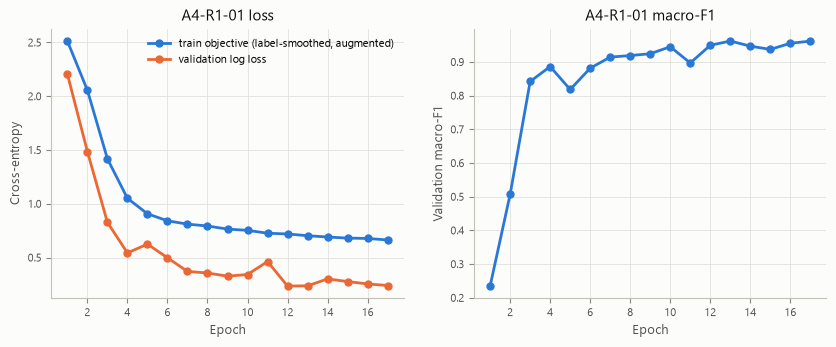

In [4]:
r1 = runner.run("A4-R1-01", "first A4 run: TC-ResNet8-1.5 (3 residual blocks, kernel 9), log-mel 64, no augmentation",
                "default configuration from Plan.md Phase 5", a4_fit_predict("A4-R1-01", DEFAULT), copy.deepcopy(DEFAULT))
print(f"best epoch {r1['extra']['best_epoch']} of {r1['extra']['epochs_run']} · {r1['extra']['n_params']:,} parameters · "
      f"receptive field {r1['extra']['receptive_field_ms']} ms · temperature {r1['extra']['temperature']:.2f}")
axes = plot_learning_curves(r1["extra"]["history"], title="A4-R1-01")
save_figure(axes[0].figure, "a4_r1_learning_curves")
plt.show()

**Observations → next step (A4, R1)**
- **The default TC-ResNet is already competitive.** With no augmentation it reaches log loss 0.176 and 94.9% accuracy. That is level with the tuned HMM (0.180, 95.2%), and better than A3's default run (0.214, 94.6%), with 146K parameters against A3's 630K.
- **Early stopping at epoch 17; best epoch 12.** Validation loss falls quickly, then jumps (epochs 5 and 11) before levelling off, while the training objective keeps falling slowly. The model is starting to fit the training clips more closely than it generalises. With ~245 clips per word, that points to regularisation.
- **→ Next:** R2 starts with augmentation, as for A3, then tests the input representation, the window length, the architecture and the learning rate.

## R2 — greedy one-factor-at-a-time search
Each step changes one factor of the **current best** configuration, and the change is kept only if validation log loss improves. The factors mirror A3's where they apply, so the two architectures can be compared factor by factor:

| Run | Change | Question |
|---|---|---|
| 01 | SpecAugment | Does masking regularise the convolutional model as it did the recurrent one? |
| 02 | Full augmentation (+ shift, tempo, noise) | Does simulated speaker and recording variation help a convolutional model? |
| 03 | MFCC-40 + Δ + ΔΔ input | Choi et al. used MFCCs: are they better than log-mel for A4? |
| 04 / 05 | 1.0 s / 2.0 s window | How much temporal context does a convolution need? |
| 06 | Silence trim instead of the energy window | Is the energy window also essential for a convolutional model? |
| 07 | 6 residual blocks (TC-ResNet14) | Does more depth, and so more stacked context, help? |
| 08 | Kernel 15 instead of 9 | Do wider temporal filters help? |
| 09 | Width 1.0 instead of 1.5 | Is a smaller model (69K parameters on MFCC-40) enough? |
| 10 / 11 | Learning rate 5e-4 / 2e-3 | Sensitivity to the learning rate |

In [5]:
best_cfg, best_run = copy.deepcopy(DEFAULT), r1
decisions = []


def try_change(exp_id, change, rationale, **overrides):
    '''Run the current best configuration with one change; keep the change if val log loss improves.'''
    global best_cfg, best_run
    cfg = copy.deepcopy(best_cfg)
    for section, values in overrides.items():
        cfg[section] = values if not isinstance(values, dict) else {**cfg[section], **values}
    r = runner.run(exp_id, change, rationale, a4_fit_predict(exp_id, cfg), cfg)
    kept = r["metrics"]["log_loss"] < best_run["metrics"]["log_loss"]
    decisions.append({"exp_id": exp_id, "change": change, "val_logloss": r["metrics"]["log_loss"],
                      "best_before": best_run["metrics"]["log_loss"], "kept": kept})
    if kept:
        best_cfg, best_run = cfg, r
    print(f"   → {'KEPT' if kept else 'rejected'} (current best: {best_run['exp_id']}, "
          f"log loss {best_run['metrics']['log_loss']:.3f})")


try_change("A4-R2-01", "+ SpecAugment (2 time masks <= 20 frames, 2 frequency masks <= 8 bands)",
           "only ~245 clips per word: masking should reduce over-fitting", augment="specaugment")
try_change("A4-R2-02", "full augmentation: SpecAugment + time shift + tempo 0.9-1.1x + noise at 10-30 dB SNR",
           "simulate speaker-rate and recording variation (synthetic only: no external data allowed)", augment="full")

A4-R2-01 [reused] log loss 0.179 · acc 95.9% · macro-F1 0.959 · ECE 0.024 · tisa/sita 0.0% · 0.4 min


   → rejected (current best: A4-R1-01, log loss 0.176)
A4-R2-02 [reused] log loss 0.140 · acc 96.2% · macro-F1 0.962 · ECE 0.024 · tisa/sita 0.0% · 0.9 min


   → KEPT (current best: A4-R2-02, log loss 0.140)


In [6]:
MFCC40 = {"feature": "mfcc", "crop": "energy", "seconds": 1.5, "n_mfcc": 40}
try_change("A4-R2-03", "MFCC-40 + delta + delta-delta (120 channels) instead of log-mel 64",
           "Choi et al. used MFCC inputs; test them against the less-compressed log-mel", features=MFCC40)
try_change("A4-R2-04", "1.0 s window instead of 1.5 s", "less silence around the word, but long words may be cut",
           features={"seconds": 1.0})
try_change("A4-R2-05", "2.0 s window instead of 1.5 s", "more context for long words (hapana), more silence for short ones",
           features={"seconds": 2.0})
try_change("A4-R2-06", "silence trim (top_db 30) + fixed length instead of the energy window",
           "the other way of locating the word; it failed for the HMM and for A3", features={"crop": "trim"})

A4-R2-03 [reused] log loss 0.133 · acc 96.5% · macro-F1 0.965 · ECE 0.018 · tisa/sita 0.0% · 3.6 min


   → KEPT (current best: A4-R2-03, log loss 0.133)
A4-R2-04 [reused] log loss 0.152 · acc 96.2% · macro-F1 0.962 · ECE 0.020 · tisa/sita 0.0% · 1.4 min


   → rejected (current best: A4-R2-03, log loss 0.133)
A4-R2-05 [reused] log loss 0.119 · acc 97.1% · macro-F1 0.971 · ECE 0.013 · tisa/sita 0.0% · 1.3 min


   → KEPT (current best: A4-R2-05, log loss 0.119)
A4-R2-06 [reused] log loss 0.276 · acc 92.5% · macro-F1 0.926 · ECE 0.020 · tisa/sita 0.0% · 1.1 min


   → rejected (current best: A4-R2-05, log loss 0.119)


In [7]:
try_change("A4-R2-07", "6 residual blocks (TC-ResNet14) instead of 3", "more depth stacks more temporal context",
           model={"blocks": 6})
try_change("A4-R2-08", "kernel 15 instead of 9", "wider temporal filters see more of the word per layer",
           model={"kernel": 15})
try_change("A4-R2-09", "width 1.0 instead of 1.5 (fewer channels)", "is a smaller model enough with ~245 clips per word?",
           model={"width": 1.0})
try_change("A4-R2-10", "peak learning rate 5e-4 instead of 1e-3", "learning-rate sensitivity (lower)", train={"lr": 5e-4})
try_change("A4-R2-11", "peak learning rate 2e-3 instead of 1e-3", "learning-rate sensitivity (higher)", train={"lr": 2e-3})
A4_BEST = best_run
print("→ best A4 run:", A4_BEST["exp_id"])
display(pd.DataFrame(decisions).style.format({"val_logloss": "{:.3f}", "best_before": "{:.3f}"}).hide(axis="index"))

A4-R2-07 [reused] log loss 0.158 · acc 96.7% · macro-F1 0.968 · ECE 0.015 · tisa/sita 0.0% · 0.6 min


   → rejected (current best: A4-R2-05, log loss 0.119)


A4-R2-08 [reused] log loss 0.151 · acc 96.2% · macro-F1 0.962 · ECE 0.028 · tisa/sita 0.0% · 0.7 min


   → rejected (current best: A4-R2-05, log loss 0.119)
A4-R2-09 [reused] log loss 0.153 · acc 96.2% · macro-F1 0.962 · ECE 0.020 · tisa/sita 0.0% · 0.8 min


   → rejected (current best: A4-R2-05, log loss 0.119)
A4-R2-10 [reused] log loss 0.142 · acc 96.5% · macro-F1 0.965 · ECE 0.017 · tisa/sita 1.0% · 0.7 min


   → rejected (current best: A4-R2-05, log loss 0.119)
A4-R2-11 [reused] log loss 0.142 · acc 96.5% · macro-F1 0.965 · ECE 0.019 · tisa/sita 0.0% · 0.7 min


   → rejected (current best: A4-R2-05, log loss 0.119)
→ best A4 run: A4-R2-05


exp_id,change,val_logloss,best_before,kept
A4-R2-01,"+ SpecAugment (2 time masks <= 20 frames, 2 frequency masks <= 8 bands)",0.179,0.176,False
A4-R2-02,full augmentation: SpecAugment + time shift + tempo 0.9-1.1x + noise at 10-30 dB SNR,0.140,0.176,True
A4-R2-03,MFCC-40 + delta + delta-delta (120 channels) instead of log-mel 64,0.133,0.140,True
A4-R2-04,1.0 s window instead of 1.5 s,0.152,0.133,False
A4-R2-05,2.0 s window instead of 1.5 s,0.119,0.133,True
A4-R2-06,silence trim (top_db 30) + fixed length instead of the energy window,0.276,0.119,False
A4-R2-07,6 residual blocks (TC-ResNet14) instead of 3,0.158,0.119,False
A4-R2-08,kernel 15 instead of 9,0.151,0.119,False
A4-R2-09,width 1.0 instead of 1.5 (fewer channels),0.153,0.119,False
A4-R2-10,peak learning rate 5e-4 instead of 1e-3,0.142,0.119,False


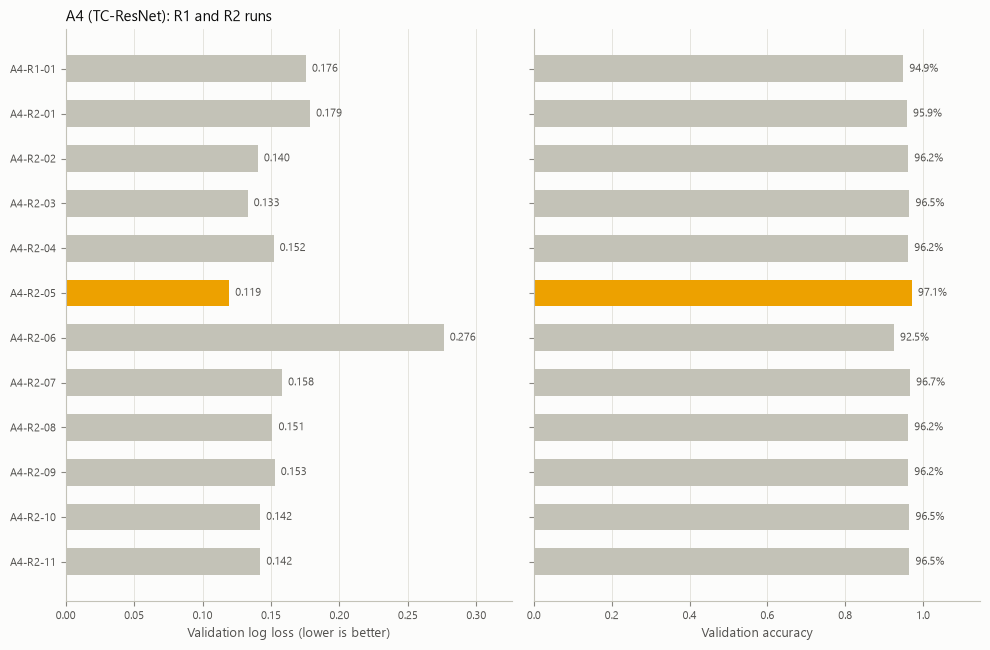

,change,val_logloss,val_acc,val_macro_f1,ece,tisa/sita,nne/nane,minutes
exp_id,,,,,,,,
A4-R1-01,"first A4 run: TC-ResNet8-1.5 (3 residual blocks, kernel 9), log-mel 64, no augmentation",0.176,94.9%,0.950,0.021,1.0%,1.0%,0.4
A4-R2-01,"+ SpecAugment (2 time masks <= 20 frames, 2 frequency masks <= 8 bands)",0.179,95.9%,0.959,0.024,0.0%,0.0%,0.4
A4-R2-02,full augmentation: SpecAugment + time shift + tempo 0.9-1.1x + noise at 10-30 dB SNR,0.140,96.2%,0.962,0.024,0.0%,0.0%,0.9
A4-R2-03,MFCC-40 + delta + delta-delta (120 channels) instead of log-mel 64,0.133,96.5%,0.965,0.018,0.0%,0.0%,3.6
A4-R2-04,1.0 s window instead of 1.5 s,0.152,96.2%,0.962,0.020,0.0%,0.0%,1.4
A4-R2-05,2.0 s window instead of 1.5 s,0.119,97.1%,0.971,0.013,0.0%,0.0%,1.3
A4-R2-06,silence trim (top_db 30) + fixed length instead of the energy window,0.276,92.5%,0.926,0.020,0.0%,1.0%,1.1
A4-R2-07,6 residual blocks (TC-ResNet14) instead of 3,0.158,96.7%,0.968,0.015,0.0%,0.0%,0.6
A4-R2-08,kernel 15 instead of 9,0.151,96.2%,0.962,0.028,0.0%,0.0%,0.7


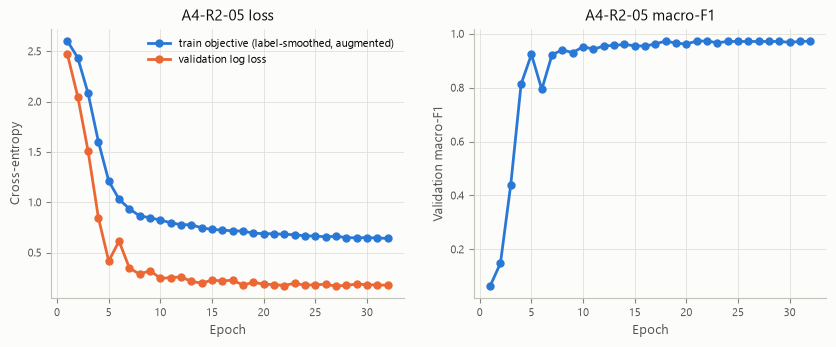

In [8]:
fig = progression_chart(runner.summary("A4"), A4_BEST["exp_id"], MODEL_COLORS["A4"], "A4 (TC-ResNet): R1 and R2 runs",
                        "a4_r2_progression")
plt.show()
display(ExperimentRunner.styled(runner.summary("A4")))
axes = plot_learning_curves(A4_BEST["extra"]["history"], title=A4_BEST["exp_id"])
save_figure(axes[0].figure, "a4_best_learning_curves")
plt.show()

**Observations → next step (A4, R2)**
- **The final configuration is A4-R2-05:** full augmentation, MFCC-40 + Δ + ΔΔ, a 2.0 s window, and TC-ResNet8-1.5 (150K parameters). Validation log loss fell from 0.176 to 0.119, and accuracy rose from 94.9% to 97.1%. That is the lowest validation log loss of any model so far.
- **Augmentation behaved differently from A3.**
  - SpecAugment alone did not help A4 (0.179 vs 0.176). For A3 it was the largest single gain (0.214 → 0.153).
  - Full augmentation (adding time shift, tempo 0.9–1.1× and noise) helped A4 (0.140). For A3 it was worse than SpecAugment alone (0.166 vs 0.153).
  - We did not isolate which transform matters. One hypothesis is tempo: a convolution's filters have fixed widths in time, while a recurrent model handles different speaking rates by itself.
- **MFCCs beat log-mel for both neural models** (A4: 0.140 → 0.133; A3: 0.153 → 0.147). The first MFCC run collapsed to chance because the augmentation filled padding with a value on the wrong scale. It is archived in `results/failed_runs/`, and the runs it made stale are in `results/superseded_runs/`.
- **A4 wants more context; A3 did not care.**
  - A4 improves steadily with the window length: 0.152 at 1.0 s, 0.133 at 1.5 s, 0.119 at 2.0 s.
  - A3 was flat: 0.144, 0.147 and 0.148.
  - A likely reason: A4 is trained with ±100 ms shifts and tempo changes, and the energy window is only centred to within 0.2 s for 90% of clips. A short window can then cut off the start or end of the word.
- **Locating the word matters most.** The silence trim is the worst A4 run (0.276, 92.5%). The same was true for the HMM and for A3 (0.759).
- **The default architecture was already right.** More depth (6 blocks, 309K parameters), wider kernels (15) and a narrower network (width 1.0, 69K parameters) all did worse (0.151–0.158). So did both learning-rate changes (0.142 each).
  - The receptive field of the default (1.71 s) already spans most of the window, so the larger receptive fields of the deeper and wider-kernel models (3.95 s and 2.97 s) add no useful context.
- **Caveat: seed noise.** A4's seed spread (below) is 0.023 log loss. Apart from the silence trim, most R2 differences are within 1–1.5 seed standard deviations. They are single runs with one seed, and should be read as directions, not established effects.

## A4 against A1, A2 and A3
All four models are scored on the same 630 validation clips, using the logged predictions of the final A1 (A1-R0-03), A2 (A2-R2-03) and A3 (A3-R2-12). A3-R2-11 is the purely recurrent A3, without the convolutional front-end: the cleanest recurrent reference for this convolutional model.

,run,val log loss,val accuracy,val macro-F1,ECE,tisa/sita,nne/nane,tatu/tano,saba/sita
A1,A1-R0-03,0.725027,0.779365,0.778867,0.035461,0.066667,0.057692,0.084906,0.0
A2,A2-R2-03,0.179942,0.952381,0.952676,0.025088,0.0,0.009615,0.018868,0.009524
A3,A3-R2-12,0.133987,0.969841,0.969908,0.01626,0.0,0.0,0.0,0.009524
A3 (recurrent only),A3-R2-11,0.141766,0.969841,0.96986,0.020439,0.0,0.0,0.0,0.0
A4,A4-R2-05,0.119448,0.971429,0.971477,0.012564,0.0,0.0,0.009434,0.0


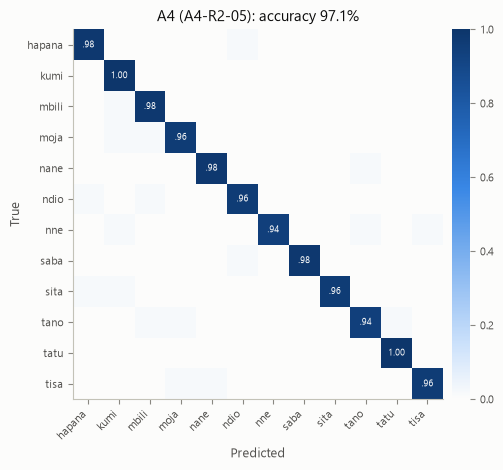

In [9]:
others = {}
for name, exp_id in (("A1", "A1-R0-03"), ("A2", "A2-R2-03"), ("A3", "A3-R2-12"), ("A3 (recurrent only)", "A3-R2-11")):
    candidates = [base / "predictions" / f"{exp_id}_seed{SEED}_val.csv" for base in (results_dir(), REPO_ROOT / "results")]
    path = next((c for c in candidates if c.exists()), candidates[0])
    if path.exists() and not SMOKE:
        df, probs = load_predictions(path)
        assert (df["id"].to_numpy() == val["id"].to_numpy()).all()
        others[name] = {"exp_id": exp_id, "probs": probs, "metrics": compute_metrics(y_val, probs, NAMES)}
models = {**others, "A4": A4_BEST}
comparison = pd.DataFrame({
    name: {"run": r["exp_id"], "val log loss": r["metrics"]["log_loss"], "val accuracy": r["metrics"]["accuracy"],
           "val macro-F1": r["metrics"]["macro_f1"], "ECE": r["metrics"]["ece"],
           **{f"{a}/{b}": pair_confusion(y_val, r["probs"].argmax(1), NAMES, a, b) for a, b in KEY_PAIRS}}
    for name, r in models.items()}).T
display(comparison)

fig, ax = plt.subplots(figsize=(5.4, 4.8))
plot_confusion_matrix(y_val, A4_BEST["probs"].argmax(1), NAMES, ax=ax,
                      title=f"A4 ({A4_BEST['exp_id']}): accuracy {A4_BEST['metrics']['accuracy']:.1%}")
fig.tight_layout()
save_figure(fig, "a4_confusion")
plt.show()

**Observations → next step (A4 against A1–A3)**
- **A4 and A3 are level on accuracy.** A4 reaches 97.1% (18 errors); A3 reaches 97.0% (19). That is one clip out of 630.
- **A4 wins on probability quality** (log loss 0.119 vs 0.134, ECE 0.013 vs 0.016), with 5.7× fewer parameters (150K vs 855K). Against the purely recurrent A3-R2-11 (0.142, 687K), the gap is larger. So on these short, isolated words, convolution over time matches recurrence at a fraction of the size.
- **The sound-alike pairs are solved.** A4 confuses *tisa/sita*, *nne/nane* and *saba/sita* 0% of the time, and *tatu/tano* once (0.9%). Its lowest recall is on *nne* and *tano* (94%).
- **The models fail on the same clips.**
  - 14 of A4's 18 errors are also A3 errors, and 12 of those also fool A2.
  - In two of them, all three models give the same wrong word with high confidence: a clip labelled *nne* heard as *tano*, and one labelled *tisa* heard as *nane*.
  - These are candidates for label noise or unusual recordings. Phase 8 will check them by listening.
- **Caveats.**
  - The A4 and A3 figures are single seed-42 runs, chosen on this validation split. The seed-variance runs below give the fairer comparison.
  - The two models were not tuned identically. A3's MFCC runs used SpecAugment with a clip-level mask fill. For MFCC inputs that fill is moderately off-scale: about 35 of 120 channels land more than 3 standard deviations out. A4 uses per-channel fill.
- **→ Next:** the Phase 7 test run with McNemar's test decides whether any gap between A3 and A4 is real.

## R3 preparation: seed variance of the final configuration (validation only)
As for A3, the final A4 configuration is retrained with the three Phase 7 seeds (42, 13, 7) and scored on **validation only**. This quantifies seed noise, and saves the checkpoints that Phase 7 will score once on the test split.

In [10]:
R3_SEEDS = (42, 13, 7)
MODEL_KEYS = ("features", "model", "train", "augment")
final_cfg = {k: A4_BEST["params"][k] for k in MODEL_KEYS}
r3 = {}
for seed in R3_SEEDS:
    seed_runner = ExperimentRunner(val, NAMES, member=MEMBER, notebook=NOTEBOOK, seed=seed, rerun=RERUN)
    r3[seed] = seed_runner.run("A4-R3-01", f"final configuration ({A4_BEST['exp_id']}) retrained with seed {seed}",
                               "seed variance on validation; checkpoints for the Phase 7 test evaluation",
                               a4_fit_predict("A4-R3-01", final_cfg, seed=seed), {**final_cfg, "seed": seed})
seed_table = pd.DataFrame({seed: {"val log loss": r["metrics"]["log_loss"], "val accuracy": r["metrics"]["accuracy"],
                                  "val macro-F1": r["metrics"]["macro_f1"], "ECE": r["metrics"]["ece"]}
                           for seed, r in r3.items()}).T
seed_table.index.name = "seed"
fmt = {"val log loss": "{:.3f}", "val accuracy": "{:.1%}", "val macro-F1": "{:.3f}", "ECE": "{:.3f}"}
display(seed_table.style.format(fmt))
display(seed_table.agg(["mean", "std"]).style.format(fmt))

A4-R3-01 [reused] log loss 0.119 · acc 97.1% · macro-F1 0.971 · ECE 0.013 · tisa/sita 0.0% · 1.0 min


A4-R3-01 [reused] log loss 0.124 · acc 96.7% · macro-F1 0.967 · ECE 0.016 · tisa/sita 0.0% · 1.0 min


A4-R3-01 [reused] log loss 0.161 · acc 96.5% · macro-F1 0.965 · ECE 0.018 · tisa/sita 0.0% · 0.6 min


,val log loss,val accuracy,val macro-F1,ECE
seed,,,,
42,0.119,97.1%,0.971,0.013
13,0.124,96.7%,0.967,0.016
7,0.161,96.5%,0.965,0.018


,val log loss,val accuracy,val macro-F1,ECE
mean,0.135,96.8%,0.968,0.015
std,0.023,0.3%,0.003,0.003


**Observations → next step (A4, seed variance)**
- **On average A4 and A3 tie.** Over seeds 42, 13 and 7, A4 reaches log loss 0.135 ± 0.023 and accuracy 96.8% ± 0.3. A3 reaches 0.137 ± 0.004 and 96.9% ± 0.2. A4's lead as a single run (0.119 vs 0.134) is mostly seed luck.
  - Seed 42 is also the seed the R2 search used to pick the configuration, so its score is optimistically biased.
  - Seed 42 reproduces A4-R2-05 exactly (0.1194), so training on the GPU is deterministic.
- **A4 is roughly six times less stable across seeds than A3 (standard deviation 0.023 vs 0.004),** and one run explains most of it.
  - Seed 7 stopped at epoch 16 of 40 (best epoch 11). Its validation loss stalled around 0.22–0.28 for five epochs, which triggered early stopping.
  - That was still in the high-learning-rate phase of the one-cycle schedule. Seeds 42 and 13 kept improving until epochs 26–27 (raw validation loss 0.167–0.168, against 0.217 for seed 7).
  - Patience 5 is therefore too short for A4 under this schedule.
- **→ Next:** Phase 7 scores the three saved checkpoints on the test split as they are. Retuning the patience now would mean selecting on validation after seeing these results, so it is left as future work: a patience of about 10, or no early stopping before the learning rate starts to decay.

## Interpretability (Phase 8 preview, validation clips): class activation over time
TC-ResNet averages its last feature map over time before the linear layer. Applying that layer to every time step gives an exact **class activation map (CAM)**: how strongly each moment of the clip supports each word. Its average over time equals the logits.
- We plot the CAM of the predicted word, and for errors also of the true word, under each clip's spectrogram.
- We also measure how much of the predicted word's positive evidence falls on the spoken word.

A4 has no early-recognition curve like A3's. Its convolutions are centred, so every output step also looks ahead in time, and the model cannot be run while a word is still being spoken.

If a checkpoint is missing (weights are not committed), `load_a4` retrains that logged configuration to rebuild it.

In [11]:
def find_metrics(exp_id, seed=SEED):
    candidates = [base / "metrics" / f"{exp_id}_seed{seed}_val.json" for base in (results_dir(), REPO_ROOT / "results")]
    return json.loads(next(c for c in candidates if c.exists()).read_text(encoding="utf-8"))


def load_a4(exp_id, seed=SEED):
    # a trained A4 model, its training-split scaler, and the val features it expects
    cfg = {k: v for k, v in find_metrics(exp_id, seed)["params"].items() if k in MODEL_KEYS}
    path = checkpoints_dir() / f"{exp_id}_seed{seed}.pt"
    if not path.exists():
        print(f"{path.name} not found: retraining {exp_id} (seed {seed}) to rebuild it")
        a4_fit_predict(exp_id, cfg, seed=seed)()
    X_va = cached_features(val, **cfg["features"])
    model, scaler, _ = load_checkpoint(path, lambda: TCResNet(n_features=X_va.shape[-1], **cfg["model"]))
    return model, scaler, X_va, cfg


def frame_loudness(logmel_db):
    # per-frame loudness (dB) from a log-mel window: mean power over the mel bands
    return 10 * np.log10((10 ** (logmel_db / 10)).mean(axis=-1))


model, scaler, X_cam, cam_cfg = load_a4(A4_BEST["exp_id"])
with torch.no_grad():
    logits, cam = model(torch.from_numpy(scaler.transform(X_cam)), return_cam=True)
probs = torch.softmax(logits / A4_BEST["extra"]["temperature"], 1).numpy()   # calibrated, as logged
cam = cam.numpy()                                                           # (clips, words, T')
pred, conf = probs.argmax(1), probs.max(1)
print(f"receptive field {model.receptive_field_frames() * 10} ms · CAM resolution {X_cam.shape[1] / cam.shape[2] * 10:.0f} ms per step")

# Log-mel of the same window, for display and to locate the word.
S_cam = cached_features(val, **{**{k: v for k, v in cam_cfg["features"].items() if k != "n_mfcc"}, "feature": "logmel"})
n_frames = S_cam.shape[1]
steps = np.linspace(0, n_frames - 1, cam.shape[2])
cam_frames = np.stack([np.interp(np.arange(n_frames), steps, cam[i, pred[i]]) for i in range(len(pred))])
loud = frame_loudness(S_cam)
word_frames = loud >= loud.max(axis=1, keepdims=True) - 25
positive = np.clip(cam_frames, 0, None)
share_on_word = (positive * word_frames).sum(1) / np.maximum(positive.sum(1), 1e-9)
print(f"share of the predicted word's positive evidence on the word's frames: median {np.median(share_on_word):.1%} "
      f"(the word covers a median {np.median(word_frames.mean(1)):.0%} of the window)")

receptive field 1710 ms · CAM resolution 77 ms per step


share of the predicted word's positive evidence on the word's frames: median 62.3% (the word covers a median 26% of the window)


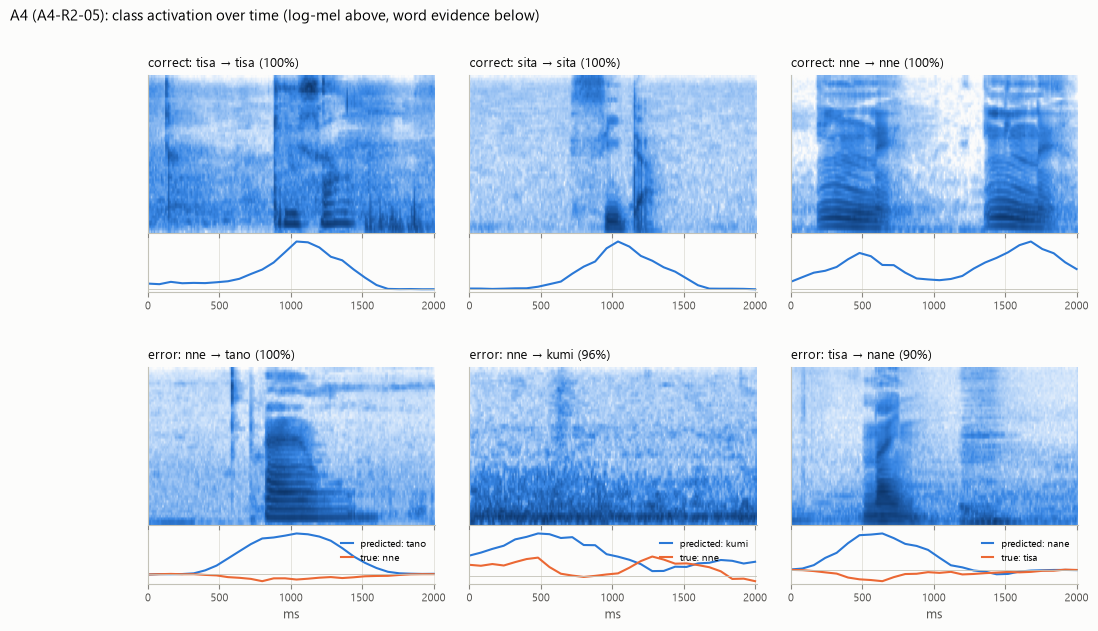

In [12]:
picks = []
for w in ("tisa", "sita", "nne"):
    c = NAMES.index(w)
    idx = np.where((y_val == c) & (pred == c))[0]
    if len(idx):
        picks.append(("correct", idx[np.argmax(conf[idx])]))
wrong = np.where(pred != y_val)[0]
picks += [("error", i) for i in wrong[np.argsort(-conf[wrong])][:3]]

cols = 3
fig = plt.figure(figsize=(12, 6.6))
outer = fig.add_gridspec(2, cols, hspace=0.35, wspace=0.12)
frame_ms = np.arange(n_frames) * 10
cam_ms = steps * 10
for k, (kind, i) in enumerate(picks[: 2 * cols]):
    inner = outer[k // cols, k % cols].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.06)
    ax_s = fig.add_subplot(inner[0])
    ax_c = fig.add_subplot(inner[1], sharex=ax_s)
    ax_s.imshow(S_cam[i].T, origin="lower", aspect="auto", cmap=blue_cmap(), extent=[0, frame_ms[-1] + 10, 0, S_cam.shape[2]])
    ax_s.set_yticks([])
    ax_s.grid(False)
    ax_s.tick_params(labelbottom=False)
    ax_s.set_title(f"{kind}: {NAMES[y_val[i]]} → {NAMES[pred[i]]} ({conf[i]:.0%})", fontsize=9, loc="left")
    ax_c.plot(cam_ms, cam[i, pred[i]], color=SERIES[0], lw=1.5, label=f"predicted: {NAMES[pred[i]]}")
    if pred[i] != y_val[i]:
        ax_c.plot(cam_ms, cam[i, y_val[i]], color=SERIES[1], lw=1.5, label=f"true: {NAMES[y_val[i]]}")
        ax_c.legend(loc="upper right", fontsize=7, handlelength=1.2)
    ax_c.axhline(0, color="#c3c2b7", lw=0.6)
    ax_c.set_yticks([])
    ax_c.grid(axis="y", visible=False)
    if k // cols == 1:
        ax_c.set_xlabel("ms")
fig.suptitle(f"A4 ({A4_BEST['exp_id']}): class activation over time (log-mel above, word evidence below)",
             x=0.01, ha="left", fontsize=11)
save_figure(fig, "a4_cam_examples")
plt.show()

**Observations → next step (A4, class activation over time)**
- **The evidence concentrates on the word, but not exclusively.** A median 62% of the predicted word's positive evidence falls on the word's frames, which cover a median 26% of the window. That is 2.4 times more than if the evidence were spread evenly.
- **The remaining evidence spills into the surrounding silence.** Each CAM step sees 1.71 s of input, most of the 2.0 s window, so a step centred on silence still sees the word. The CAM is also coarse: one step per 77 ms, after three stride-2 blocks.
  - So this map shows *when* the model's evidence peaks, not a sharp alignment. A3's attention is sharper: a median 100% of its weight falls on the word.
- **Correct examples.** For *tisa* and *sita*, the evidence forms one peak over the word. One *nne* clip contains the word twice, and the CAM peaks under each repetition: the model adds up evidence from both.
- **Errors.** The most confident error is the *nne* clip that all three models hear as *tano*: its evidence for *nne* stays at or below zero throughout. In the *nne* → *kumi* error, broadband low-frequency noise covers the whole clip and the word is faint. That error's evidence is spread over the clip rather than peaking.
- **→ Next:** Phase 8 listens to the shared, confident errors. Label noise and very noisy recordings are the likely causes.

## Save the selected configuration

In [13]:
cfg_out = {"approach": "A4", "exp_id": A4_BEST["exp_id"], "selected_by": "lowest validation log loss over rounds R1 and R2",
           "params": A4_BEST["params"],
           "extra": {k: v for k, v in A4_BEST["extra"].items() if k != "history"},
           "val": {k: round(A4_BEST["metrics"][k], 4) for k in ("log_loss", "accuracy", "macro_f1", "ece")}}
path = (results_dir() if SMOKE else CONFIGS_DIR) / "a4_best.yaml"   # smoke runs never touch configs/
path.write_text(yaml.safe_dump(json.loads(json.dumps(cfg_out, default=float)), sort_keys=False), encoding="utf-8")
print("wrote", path)
table = build_experiment_table()
display(table[table.exp_id.str.startswith("A4")][["exp_id", "change_vs_previous", "val_logloss", "val_acc",
                                                  "val_macro_f1", "train_time_min", "gpu"]])

wrote C:\Users\Luqma\dev\projects\coursework\nlp-sequential-modeling-group21\configs\a4_best.yaml


,exp_id,change_vs_previous,val_logloss,val_acc,val_macro_f1,train_time_min,gpu
37,A4-R1-01,first A4 run: TC-ResNet8-1.5 (3 residual block...,0.1755,0.9492,0.9495,0.4071,Tesla T4
38,A4-R2-01,"+ SpecAugment (2 time masks <= 20 frames, 2 fr...",0.1786,0.9587,0.9589,0.3902,Tesla T4
39,A4-R2-02,full augmentation: SpecAugment + time shift + ...,0.1404,0.9619,0.9620,0.8955,Tesla T4
40,A4-R2-03,MFCC-40 + delta + delta-delta (120 channels) i...,0.1330,0.9651,0.9651,3.6458,cpu
41,A4-R2-04,1.0 s window instead of 1.5 s,0.1519,0.9619,0.9619,1.4057,Tesla T4
42,A4-R2-05,2.0 s window instead of 1.5 s,0.1194,0.9714,0.9715,1.3319,Tesla T4
43,A4-R2-06,silence trim (top_db 30) + fixed length instea...,0.2762,0.9254,0.9257,1.1046,Tesla T4
44,A4-R2-07,6 residual blocks (TC-ResNet14) instead of 3,0.1581,0.9667,0.9676,0.6294,Tesla T4
45,A4-R2-08,kernel 15 instead of 9,0.1511,0.9619,0.9621,0.7380,Tesla T4
46,A4-R2-09,width 1.0 instead of 1.5 (fewer channels),0.1527,0.9619,0.9621,0.7812,Tesla T4
